# Comparacion entre histogramas de gamma Rayleihtn en agua pura para diferentes energias

In [2]:
import json
import matplotlib.pyplot as plt
import numpy as np
import math

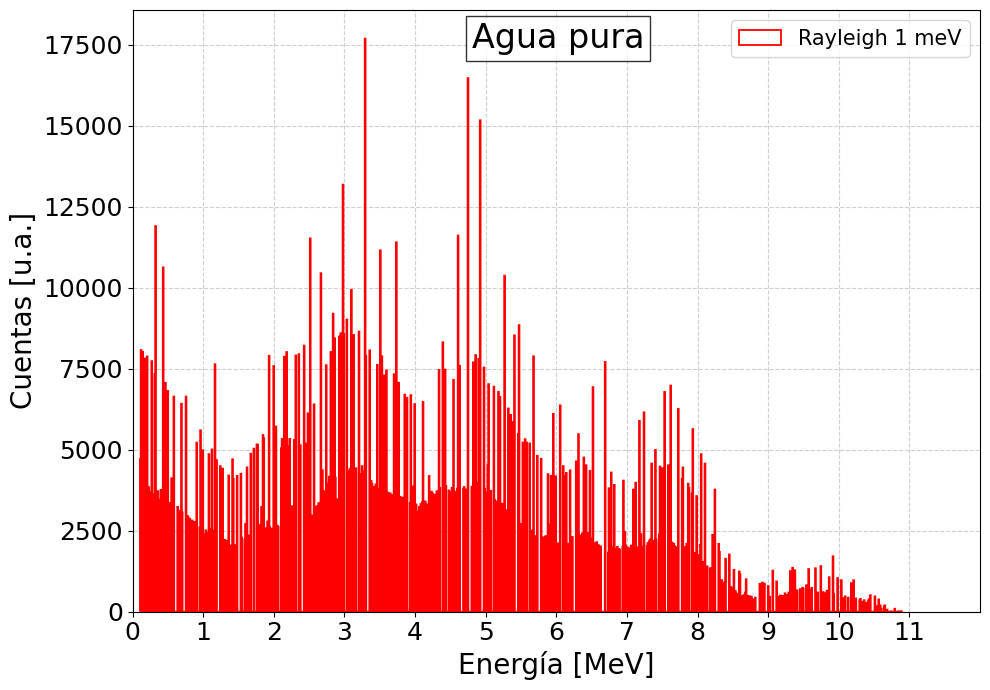

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# === Rango de filtrado espacial ===
x_min, x_max = -480.0, 480.0
y_min, y_max = -480.0, 480.0
z_min, z_max = 0.0, 1330.05

# === Lista de archivos a leer ===
archivos = [
    ("Espectro-energia-neutrones-AmBe-241.txt",     "1 meV")
]
#    ("../10000meV/Agua-pura/procesos_filtrados/Ray/Rayl.txt", "10 keV"),
#    ("../100000meV/Agua-pura/procesos_filtrados/Ray/Rayl.txt","100 keV"),
#    ("../1000000meV/Agua-pura/procesos_filtrados/Ray/Rayl.txt","1 MeV")

# === Colores para cada histograma (ROOT-like) ===
colores = ["red", "blue", "green", "black", "magenta", "orange", "purple"]

# === Función para cargar y filtrar datos ===
def cargar_datos(path):
    valores = []
    with open(path, "r") as file:
        for line in file:
            parts = line.split()
            if len(parts) < 1:
                continue

            try:
                value = float(parts[0])
                valores.append(value)
                #if x_min <= x <= x_max and y_min <= y <= y_max and z_min <= z <= z_max:
                    #valores.append(value)

            except ValueError:
                continue
    return valores


# === Figura ===
plt.figure(figsize=(10, 7))

# === Leer y graficar los 7 histogramas ===
for (ruta, etiqueta), color in zip(archivos, colores):
    datos = cargar_datos(ruta)

    plt.hist(
        datos,
        bins=1000,
        histtype="step",
        linewidth=1.3,
        color=color,
        label=f"Rayleigh {etiqueta}"
    )

# === Configuración del gráfico ===
plt.xlabel("Energía [MeV]", fontsize=20)
plt.ylabel("Cuentas [u.a.]", fontsize=20)

plt.xlim(0, 12)
plt.xticks(np.arange(0, 12, 1))

plt.grid(True, linestyle="--", alpha=0.6)

plt.tick_params(axis='x', labelsize=18)
plt.tick_params(axis='y', labelsize=18)
plt.text(
    0.4, 0.98,
    #r"$^{16}\mathrm{O} + n \rightarrow\ ^{17}\mathrm{O}^{*} \rightarrow\ ^{17}\mathrm{O} + \gamma$",
    f"Agua pura",
    transform=plt.gca().transAxes,
    fontsize=24,
    verticalalignment='top',
    bbox=dict(facecolor='white', edgecolor='black', alpha=0.8)
)


plt.legend(fontsize=15, loc="upper right")

plt.tight_layout()

# Guardar
plt.savefig("Espectros-energia-AmBe-241.png")
plt.savefig("Espectros-energia-AmBe-241.pdf")

plt.show()


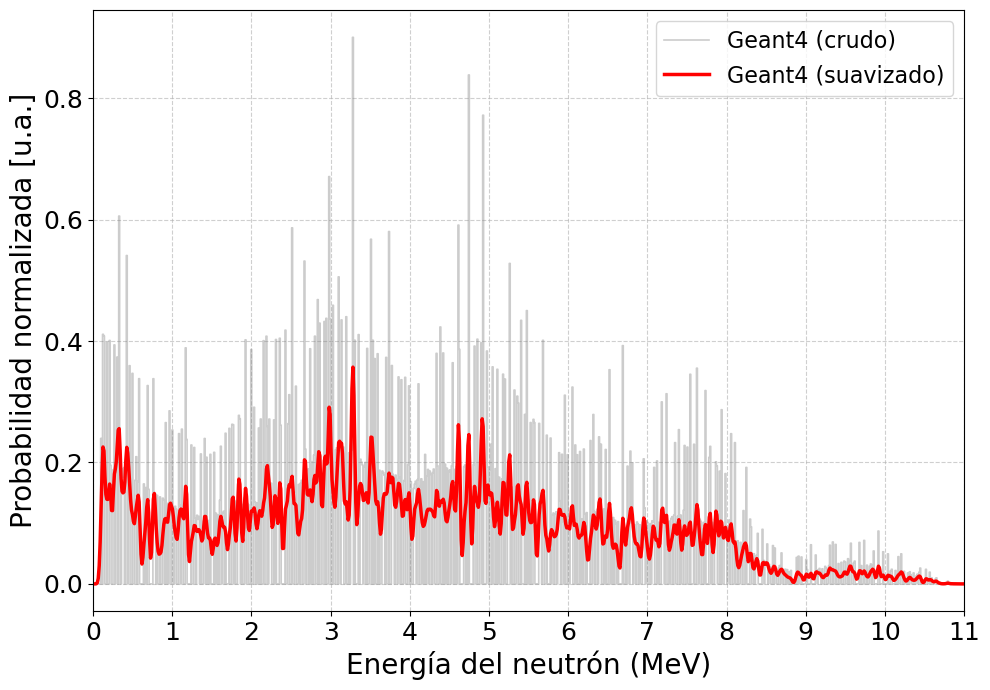

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import gaussian_filter1d

# ===============================
# Cargar datos
# ===============================
def cargar_datos(path):
    valores = []
    with open(path, "r") as file:
        for line in file:
            try:
                valores.append(float(line.split()[0]))
            except:
                continue
    return np.array(valores)

# ===============================
# Archivo
# ===============================
archivo = "Espectro-energia-neutrones-AmBe-241.txt"
datos = cargar_datos(archivo)

# ===============================
# Histograma explícito
# ===============================
bins = 1000
hist, edges = np.histogram(datos, bins=bins, range=(0, 12))
centros = 0.5 * (edges[:-1] + edges[1:])

# ===============================
# Normalización por área
# ===============================
hist_norm = hist / np.trapz(hist, centros)

# ===============================
# Suavizado gaussiano (suave)
# ===============================
sigma_bins = 1.5
hist_suave = gaussian_filter1d(hist_norm, sigma=sigma_bins)

# ===============================
# Gráfica
# ===============================
plt.figure(figsize=(10, 7))

# Datos crudos (opcional)
plt.step(
    centros, hist_norm,
    where="mid",
    color="gray",
    alpha=0.4,
    linewidth=1.2,
    label="Geant4 (crudo)"
)

# Datos suavizados
plt.plot(
    centros, hist_suave,
    color="red",
    linewidth=2.5,
    label="Geant4 (suavizado)"
)

# ===============================
# Estética (tesis)
# ===============================
plt.xlabel("Energía del neutrón (MeV)", fontsize=20)
plt.ylabel("Probabilidad normalizada [u.a.]", fontsize=20)

plt.xlim(0, 11)
plt.xticks(np.arange(0, 12, 1))
plt.grid(True, linestyle="--", alpha=0.6)

plt.tick_params(axis='x', labelsize=18)
plt.tick_params(axis='y', labelsize=18)

plt.legend(fontsize=16, loc="upper right")

plt.tight_layout()

# Guardar
plt.savefig("Espectro-AmBe-241-suavizado.png", dpi=300)
plt.savefig("Espectro-AmBe-241-suavizado.pdf")

plt.show()


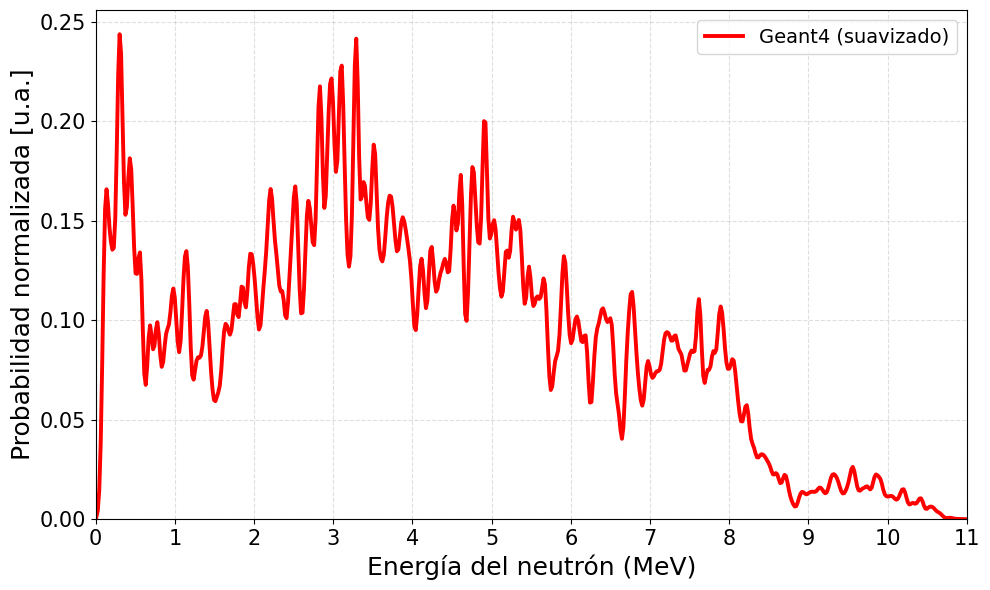

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# ===============================
# Cargar datos Geant4
# ===============================
def cargar_datos(path):
    return np.loadtxt(path)

datos = cargar_datos("Espectro-energia-neutrones-AmBe-241.txt")

# ===============================
# Histograma
# ===============================
bins = 600
Emin, Emax = 0.0, 11.0

hist, edges = np.histogram(datos, bins=bins, range=(Emin, Emax))
centros = 0.5 * (edges[:-1] + edges[1:])

# ===============================
# Normalización por área
# ===============================
hist_norm = hist / np.trapz(hist, centros)

# ===============================
# Suavizado (NO altera la física)
# ===============================
sigma_bins = 1.8
hist_suave = gaussian_filter1d(hist_norm, sigma=sigma_bins)

# ===============================
# Figura
# ===============================
plt.figure(figsize=(10, 6))

plt.plot(
    centros,
    hist_suave,
    color="red",
    linewidth=2.8,
    label="Geant4 (suavizado)"
)

# ===============================
# Estética
# ===============================
plt.xlabel("Energía del neutrón (MeV)", fontsize=18)
plt.ylabel("Probabilidad normalizada [u.a.]", fontsize=18)

plt.xlim(0, 11)
plt.ylim(bottom=0)

plt.xticks(np.arange(0, 12, 1))
plt.tick_params(axis='both', labelsize=15)

plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(fontsize=14, frameon=True)

plt.tight_layout()

plt.savefig("Espectro-AmBe-Geant4-suavizado-1.png", dpi=300)
plt.savefig("Espectro-AmBe-Geant4-suavizado-1.pdf")

plt.show()


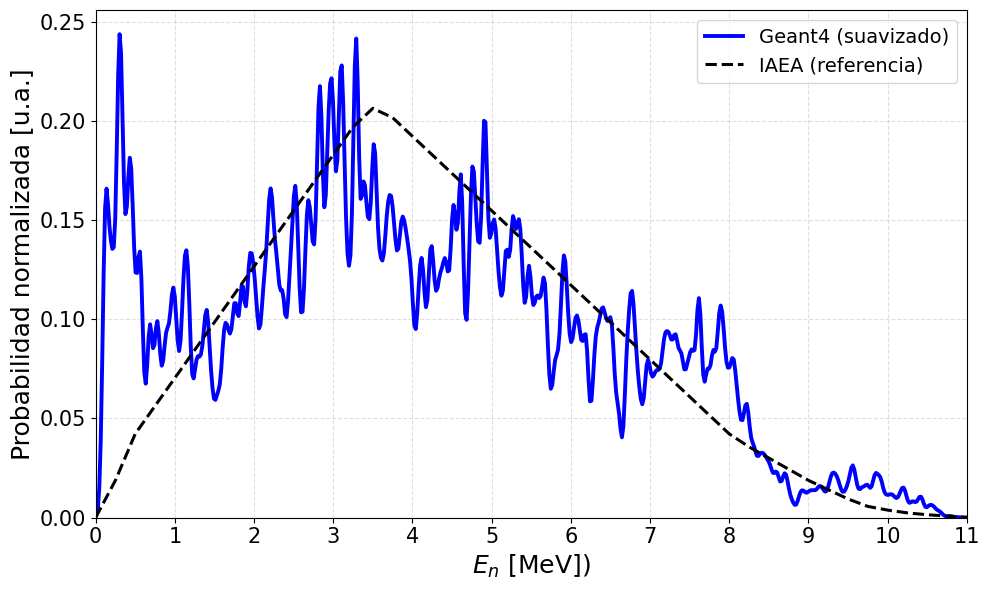

In [11]:
# ===============================
# Cargar espectro IAEA
# ===============================
E_IAEA, P_IAEA = np.loadtxt("AmBe_IAEA.txt", unpack=True)

# Normalización por área
P_IAEA = P_IAEA / np.trapz(P_IAEA, E_IAEA)

# ===============================
# Superposición
# ===============================
plt.figure(figsize=(10, 6))

plt.plot(
    centros,
    hist_suave,
    color="blue",
    linewidth=2.8,
    label="Geant4 (suavizado)"
)

plt.plot(
    E_IAEA,
    P_IAEA,
    color="black",
    linestyle="--",
    linewidth=2.2,
    label="IAEA (referencia)"
)

plt.xlabel("$E_{n}$ [MeV]", fontsize=18)
plt.ylabel("Probabilidad normalizada [u.a.]", fontsize=18)

plt.xlim(0, 11)
plt.ylim(bottom=0)

plt.xticks(np.arange(0, 12, 1))
plt.tick_params(axis='both', labelsize=15)

plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(fontsize=14)

plt.tight_layout()

plt.savefig("Espectro-AmBe-Geant4-vs-IAEA.png", dpi=300)
plt.savefig("Espectro-AmBe-Geant4-vs-IAEA.pdf")

plt.show()


# Histogramas agua pura

In [37]:
# Nombre del archivo de datos
archivo_datos = "Espectro-energia-neutrones-AmBe-241.txt"
# Lista para almacenar los datos
datos_Ray_AP_1meV = []
# Abrir el archivo y leer los datos
with open(archivo_datos, 'r') as archivo:
    for linea in archivo:
        #Cada línea contiene un solo número en formato de texto
        valor = float(linea.strip())  # Convierte el texto a un número de punto flotante
        datos_Ray_AP_1meV.append(valor)

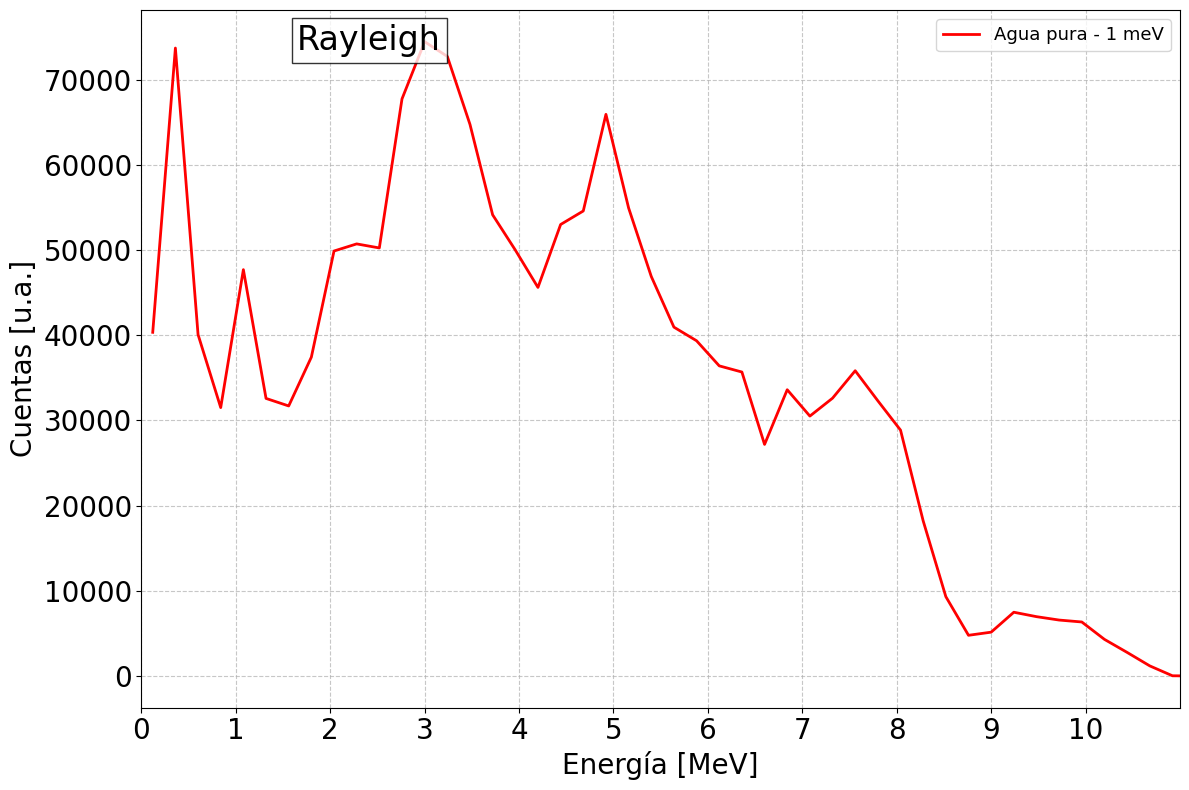

In [38]:
import matplotlib.pyplot as plt
import numpy as np
import math
from matplotlib.lines import Line2D

# === Configuración general ===
numero_bins = 50
inicio, fin = 0, 12

# === Función para graficar polígonos de frecuencia ===
def plot_polygon(data, color, label, linestyle='-'):
    counts, bins = np.histogram(data, bins=numero_bins, range=(inicio, fin))
    bin_centers = (bins[:-1] + bins[1:]) / 2  
    plt.plot(bin_centers, counts, linestyle=linestyle, color=color, label=label, linewidth=2)

# === Crear figura ===
plt.figure(figsize=(12, 8))

# === Colores consistentes para cada energía ===
colores = {
    '1meV': 'red'
}

# === Graficar Agua Pura (líneas continuas) ===
plot_polygon(datos_Ray_AP_1meV, color=colores['1meV'], label='Agua pura - 1 meV', linestyle='-')

# === Formato general ===
plt.xlabel('Energía [MeV]', fontsize=20)
plt.ylabel('Cuentas [u.a.]', fontsize=20)
plt.xlim(0, 11)
#plt.ylim(0, 950)
plt.xticks(np.arange(0, 11, 1))
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tick_params(axis='x', which='both', labelsize=20)
plt.tick_params(axis='y', which='both', labelsize=20)

# === Leyenda personalizada ===
plt.legend(fontsize=13, ncol=2, loc='upper right')

# === Título del gráfico ===
plt.text(
    0.15, 0.98,
    "Rayleigh",
    transform=plt.gca().transAxes,
    fontsize=24,
    verticalalignment='top',
    bbox=dict(facecolor='white', edgecolor='black', alpha=0.8)
)

# === Guardar y mostrar ===
plt.tight_layout()
plt.savefig('Espectros-energia-AmBe-241-1.png', format='png')
plt.savefig('Espectros-energia-AmBe-241-1.pdf', format='pdf')
plt.show()
